In [1]:
import sys,os
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from GaussianProcess.engine import GPCalculator

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

# 1) Create data

## Settings

In [2]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

x_label = r'$x$'
y_label = r'$f(x)$'

In [3]:
from parametric_approach.polynomial import PolynomialFit
theory = PolynomialFit(None,None,order=3)
theory_model = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

## Data generation

In [4]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

## Plot data

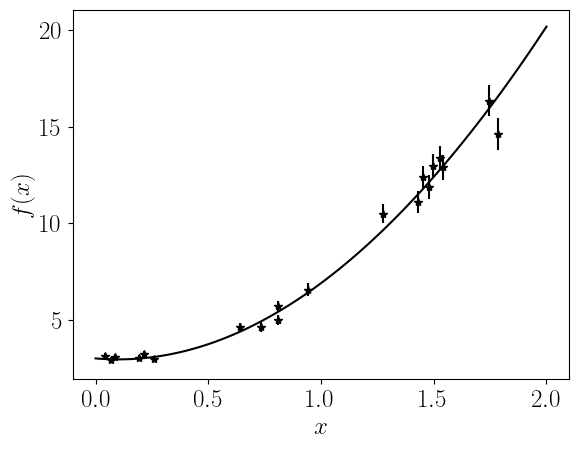

In [5]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
if theory_model != None:
    plt.plot(xplot,theory_model(xplot)['f'],color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# 2) Observable reconstruction

## Settings

In [6]:
N_recon = 5
xmin_recon = 0.1
xmax_recon = 1.8
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

possible_derivatives = ['f','int','d1','d2']

kernel = 'RBF'

#methods = ['MAP']
methods = ['BAYESIAN','MAP']
colors  = [red,yellow]

## Perform reconstruction

In [7]:
gp = GPCalculator(dataset,covmat,kernel_type=kernel)

In [8]:
covmats = []
meandf = []
for method in methods:
    tini = time()
    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)
    means['Method'] = method
    covmats.append(joint_cov)
    meandf.append(means)

    print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

allmeans = pd.concat(meandf,ignore_index=True)

Removed no burn in
GP (BAYESIAN) done in 132.49 s
GP (MAP) done in 1.21 s


## Plot reconstruction

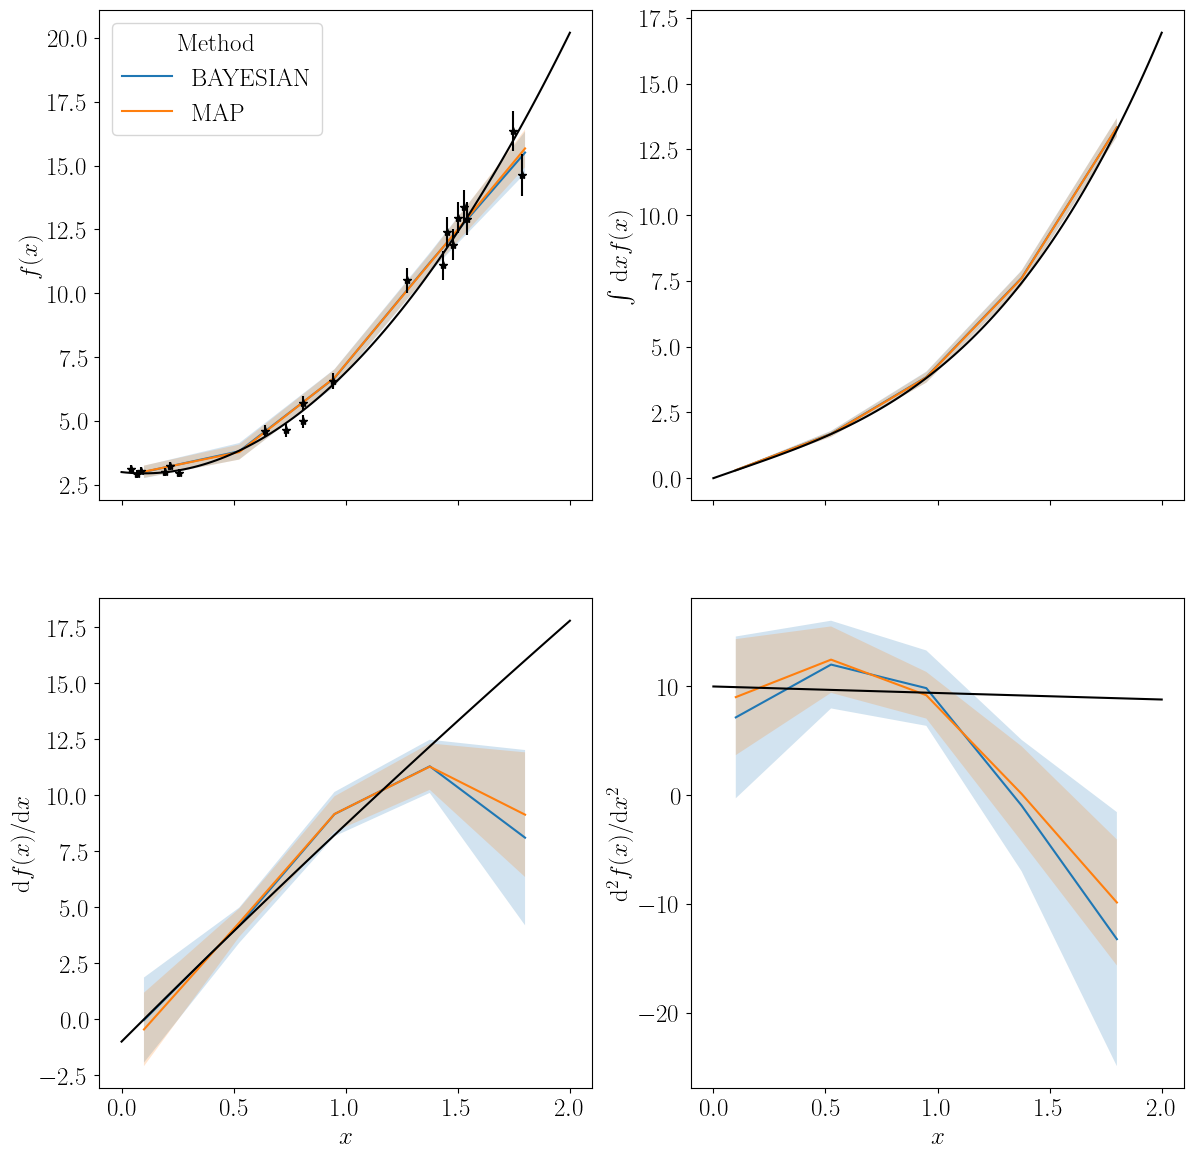

In [9]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in methods:
        df = allmeans[allmeans['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method')
    else:
        sb.lineplot(allmeans,x='x',y=deriv,ax=axes[i,j],hue='Method',legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

# 3) Obtain derived function

$$D(x)=f'(x)/f(x)$$

In [10]:
needed = ['f','d1']

In [11]:
from tools.samplers_interface import SamplersInterface

sampler = SamplersInterface(sampler='Nautilus',run_options='poor',chatty=True)

## Selecting reconstruction results

In [12]:
def get_datasets(df,joint_cov,needed_funcs):
    
    needed_cols  = ['f_'+str(ind) for ind in range(N_recon)]+['d1_'+str(ind) for ind in range(N_recon)]
    
    recon_data = df.drop(columns=[col for col in df.columns if col not in ['x']+needed_funcs])
    
    recon_cov = joint_cov.drop(columns=[col for col in joint_cov.columns if col not in needed_cols])
    
    recon_cov = recon_cov.drop(index=[col for col in recon_cov.index if col not in needed_cols])
    
    invcov = pd.DataFrame(np.linalg.inv(recon_cov.values),columns=recon_cov.columns,index=recon_cov.index)

    return recon_data,invcov

## Set free parameters

In [13]:
def get_freepars(means):
    f_pars = {'f_{}'.format(ind): {'prior': [means.loc[ind,'f']-5*means.loc[ind,'f_err'],
                                             means.loc[ind,'f']+5*means.loc[ind,'f_err']],
                                  'latex': r'$f_{}$'.format(ind)} for ind in range(N_recon)}
    
    d1_pars = {'d1_{}'.format(ind): {'prior': [means.iloc[ind]['d1']-5*means.iloc[ind]['d1_err'],
                                               means.iloc[ind]['d1']+5*means.iloc[ind]['d1_err']],
                                    'latex': r'$d1_{}$'.format(ind)} for ind in range(N_recon)}
    
    
    parameters = f_pars | d1_pars

    return parameters

## Set likelihood and nautilus runner

In [14]:
def run_case(df,joint_cov):

    df = allmeans[allmeans['Method']==method].reset_index(drop=True)
    joint_cov = covmats[ind]

    recon_data,invcov = get_datasets(df,joint_cov,needed)
    parameters = get_freepars(df)

    derived = {'D{}'.format(ind): {'latex': 'D_{}'.format(ind)} for ind in range(N_recon)}
    
    def likelihood(param_dict):
    
        theoryvec = np.array([param_dict[par] for par in invcov.columns] )
        datavec   = np.array([recon_data.iloc[int(col.split('_')[1])][col.split('_')[0]] for col in invcov.columns])
    
        diffvec = theoryvec-datavec
        loglike = -0.5*np.dot(diffvec,np.dot(invcov.values,diffvec))
        
        derived_params = [param_dict['d1_{}'.format(ind)]/param_dict['f_{}'.format(ind)] for ind in range(N_recon)]
            
        like_tuple    = [loglike]+[par for par in derived_params]
        
        full_tuple    = tuple(like_tuple)
        
        return full_tuple

    sample = sampler.run(parameters,likelihood,derived=derived)

    return sample

## Run reconstruction

In [15]:
results = {}
for ind,method in enumerate(methods):

    df = allmeans[allmeans['Method']==method].reset_index(drop=True)
    joint_cov = covmats[ind]
    
    results[method] = {'sample': run_case(df,joint_cov),
                       'color': colors[ind]}

Loaded prior into Nautilus with dimension 10
Prior keys:  ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'd1_0', 'd1_1', 'd1_2', 'd1_3', 'd1_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 42     | 1        | 2        | 29056    | N/A    | 10019 | -29.14   
NAUTILUS SAMPLING FINISHED
Removed no burn in
Loaded prior into Nautilus with dimension 10
Prior keys:  ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'd1_0', 'd1_1', 'd1_2', 'd1_3', 'd1_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 62     | 1        | 2        | 41216    | N/A    | 10049 | -45.24   
NAUTILUS SAMPLING FINISHED
Removed no burn in


## Plotting parameters

In [16]:
fiducial_recon = {'D{}'.format(ind): theory_model(x_recon[ind])['d1']/theory_model(x_recon[ind])['f'] 
                  for ind in range(N_recon)}

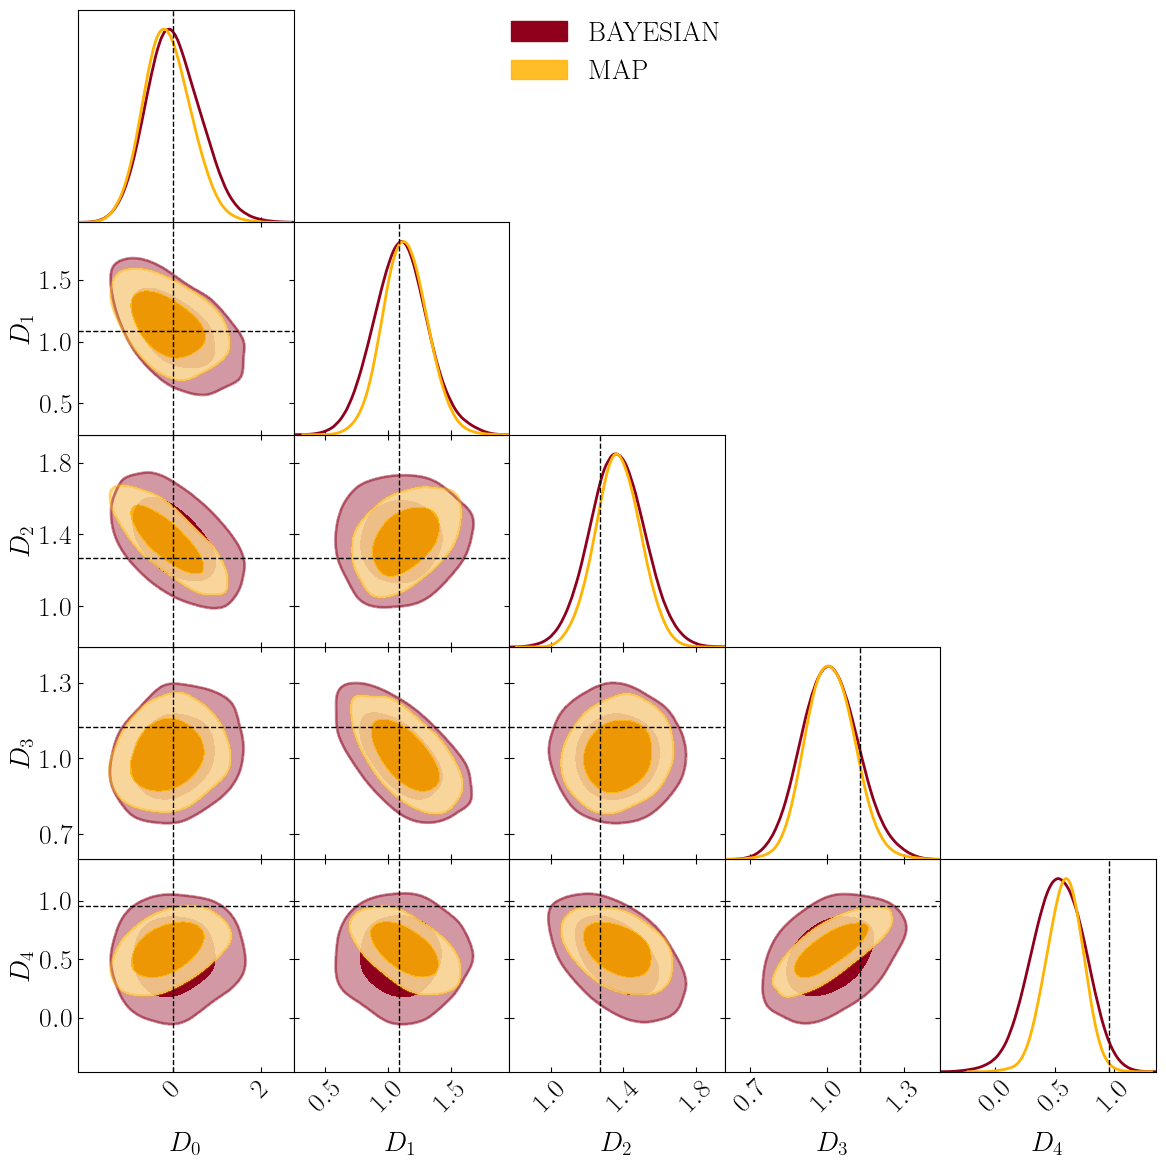

In [17]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_recon.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
                legend_labels=list(results.keys()),
                markers=fiducial_recon
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

## Plotting reconstructed function

In [18]:
for method in methods:
    sample = results[method]['sample']
    results[method]['reconstruction'] = pd.DataFrame({'x': x_recon})
    results[method]['reconstruction']['value'] = sample.getMeans()[2*N_recon:]
    results[method]['reconstruction']['error'] = np.sqrt(sample.getVars()[2*N_recon:])

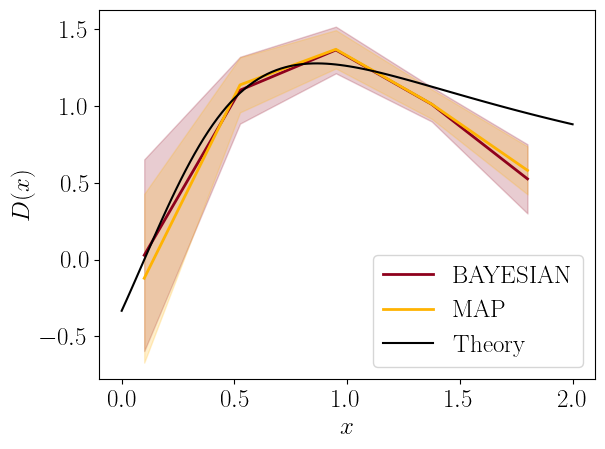

In [19]:
xplot = np.linspace(xmin,xmax,100)

plt.figure()
for method in methods:
    reconstruction = results[method]['reconstruction']
    plt.fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                     reconstruction['value']-reconstruction['error'],alpha=0.2,color=results[method]['color'])
    plt.plot(reconstruction['x'],reconstruction['value'],lw=2,color=results[method]['color'],label=method)
plt.plot(xplot,theory_model(xplot)['d1']/theory_model(xplot)['f'],color='black',label='Theory')
plt.xlabel(x_label)
plt.ylabel(r'$D(x)$')
plt.legend(loc='best');